# 00 · Setup and Simulation  *(overview / sanity check)*

**Magnetic Source Identification — Project 1 (Settgast)**

This notebook is an **optional starting point**: it installs dependencies, defines the Magnetometer Time Series Simulator (MTSS), loads the 29-station sensor array, and shows a 3D visualization of the array with example sources. Run it first if you want to confirm your environment and that `L058.txt` loads correctly.

Each experiment notebook is **fully self-contained** (it re-includes the install, simulator, and sensor-loader cells), so you can also run any experiment on its own without running this notebook first:

- `01_Experiment_1.ipynb` — broad architecture search (400 positions × 20 noise = 16,000 samples)
- `02_Experiment_2.ipynb` — loss/optimizer focus, same dataset as Exp 1
- `03_Experiment_3.ipynb` — larger dataset (3,200 × 10 = 64,000) + full evaluation & irreducible-error analysis


In [ ]:
# ============================================================
# Environment Setup — run this first
# ============================================================
# Colab ships with PyTorch and sklearn pre-installed.
# Optuna and tqdm are the only additions needed.
!pip install optuna tqdm --quiet

# Sensor location file (L058.txt):
#   - If it is already next to this notebook (e.g. a cloned repo), use it.
#   - Otherwise, on Colab, prompt for an upload.
import os
if os.path.exists('L058.txt'):
    print('Found L058.txt in the working directory \u2014 no upload needed.')
else:
    try:
        from google.colab import files
        uploaded = files.upload()  # prompts for L058.txt
    except ImportError:
        raise FileNotFoundError(
            'L058.txt not found. Place it next to this notebook (or upload it on Colab).'
        )


#### Simulator Object

In [2]:
"""
Magnetometer Time Series Simulator for Magnetic Localization Research

This module provides a high-fidelity simulator for generating synthetic
magnetometer data from dipole sources, designed for training neural networks
for magnetic source localization.

Author: Strider Settgast with Deepseek
Date: 2026-06-01
Version: 1.0.0
"""

import numpy as np
from typing import Optional, Tuple, Dict, List
from dataclasses import dataclass
import warnings
from enum import Enum


class SourceType(Enum):
    """Types of magnetic sources that can be simulated."""
    DIPOLE = "dipole"
    MONOPOLE = "monopole"  # Not physically real but useful for testing
    #QUADRUPOLE = "quadrupole"


class NoiseModel(Enum):
    """Available noise models for sensor simulation."""
    GAUSSIAN = "gaussian"
    UNIFORM = "uniform"
    MIXED = "mixed"  # Combination of Gaussian and outliers


@dataclass
class SimulatorConfig:
    """
    Configuration class for the TimeSeriesSimulator.

    Attributes:
        sensor_positions: (n_sensors, 3) array of sensor coordinates
        n_sensors: Number of sensors (auto-detected from positions)
        magnetic_constant: mu_0/(4pi) in SI units (default 1e-7 for normalized)
        default_source_bounds: [min, max] for source position cube
        default_moment_range: [min, max] for magnetic moment magnitude
        noise_std: Standard deviation for Gaussian noise
        noise_outlier_fraction: Fraction of outliers for robust testing
        random_seed: For reproducibility
        normalize_outputs: Whether to normalize target positions
        output_bounds: Bounds for output normalization (if used)
    """
    sensor_positions: np.ndarray
    magnetic_constant: float = 1e-7  # mu_0/(4pi) in SI, or 1.0 for normalized
    default_source_bounds: Tuple[float, float] = (-5.0, 5.0)
    default_moment_range: Tuple[float, float] = (0.5, 2.0)
    noise_std: float = 0.01
    noise_outlier_fraction: float = 0.01
    random_seed: Optional[int] = 42
    normalize_outputs: bool = False
    output_bounds: Optional[Tuple[float, float]] = None

    def __post_init__(self):
        """Validate configuration after initialization."""
        self.n_sensors = len(self.sensor_positions)
        if self.sensor_positions.shape[1] != 3:
            raise ValueError(f"Sensor positions must have 3 columns, got {self.sensor_positions.shape[1]}")

        if self.random_seed is not None:
            np.random.seed(self.random_seed)

        if self.output_bounds is None:
            self.output_bounds = self.default_source_bounds


class TimeSeriesSimulator:
    """
    Industry-grade simulator for magnetometer time series data.

    This class generates realistic magnetic field readings from moving or static
    dipole sources, with configurable noise, sensor layouts, and source dynamics.

    Features:
        - Static and moving source simulation
        - Multiple noise models (Gaussian, uniform, mixed)
        - Sensor noise and dropout simulation
        - Temporal correlation for realistic time series
        - Batching and streaming data generation
        - Built-in visualization tools

    Examples:
        >>> # Initialize with sensor positions
        >>> sensor_positions = np.random.rand(29, 3) * 10
        >>> sim = TimeSeriesSimulator(sensor_positions)
        >>>
        >>> # Generate static source data
        >>> X, y = sim.generate_batch(n_samples=1000)
        >>>
        >>> # Generate moving source time series
        >>> trajectory = lambda t: np.array([np.sin(t), np.cos(t), t*0.1])
        >>> X_series, y_series = sim.generate_time_series(
        ...     n_timesteps=500,
        ...     trajectory_func=trajectory
        ... )
    """

    def __init__(self, sensor_positions: np.ndarray, config: Optional[SimulatorConfig] = None):
        """
        Initialize the simulator with sensor geometry.

        Args:
            sensor_positions: (n_sensors, 3) array of sensor coordinates in meters
            config: Optional SimulatorConfig object. If None, uses defaults.
        """
        self.sensor_positions = sensor_positions
        self.n_sensors = len(sensor_positions)

        if config is None:
            config = SimulatorConfig(sensor_positions=sensor_positions)
        else:
            config.sensor_positions = sensor_positions
            config.__post_init__()

        self.config = config
        self._validate_sensor_positions()

        # Pre-compute sensor positions for efficiency
        self.sensor_positions = config.sensor_positions
        self.n_sensors = config.n_sensors
        self.n_features = self.n_sensors * 3  # Bx, By, Bz for each sensor

        # Statistics for online normalization (if needed)
        self.input_mean = None
        self.input_std = None
        self.output_mean = None
        self.output_std = None

        print(f"✅ Simulator initialized: {self.n_sensors} sensors, {self.n_features} features")

    def _validate_sensor_positions(self):
        """Validate that sensor positions are physically reasonable."""
        if np.any(np.isnan(self.sensor_positions)):
            raise ValueError("Sensor positions contain NaN values")
        if np.any(np.isinf(self.sensor_positions)):
            raise ValueError("Sensor positions contain infinite values")

        # Check for duplicate sensors (within 1mm tolerance)
        unique_positions = np.unique(np.round(self.sensor_positions, decimals=6), axis=0)
        if len(unique_positions) < self.n_sensors:
            warnings.warn(f"Duplicate sensor positions detected. {self.n_sensors - len(unique_positions)} duplicates found.")

    def monopole_field(self,
                       sensor_pos: np.ndarray,
                       source_pos: np.ndarray,
                       magnetic_charge: float) -> np.ndarray:
        """
        Calculate magnetic field from a theoretical monopole (1/r^2 falloff).
        """
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)
        if r < 1e-9:
            return np.zeros(3)

        r_hat = r_vec / r
        B = (r_hat) / (r**2)
        B *= self.config.magnetic_constant * magnetic_charge

        return B

    def dipole_field(self,
                     sensor_pos: np.ndarray,
                     source_pos: np.ndarray,
                     magnetic_moment: np.ndarray) -> np.ndarray:
        """
        Calculate magnetic field from a dipole source at a single sensor.

        Args:
            sensor_pos: (3,) array of sensor position [x, y, z]
            source_pos: (3,) array of source position [x, y, z]
            magnetic_moment: (3,) array of magnetic moment vector [mx, my, mz]

        Returns:
            (3,) array of magnetic field [Bx, By, Bz] in Tesla (or normalized units)

        Raises:
            ValueError: If inputs have incorrect shapes
        """
        # Input validation
        if sensor_pos.shape != (3,):
            raise ValueError(f"sensor_pos must be (3,), got {sensor_pos.shape}")
        if source_pos.shape != (3,):
            raise ValueError(f"source_pos must be (3,), got {source_pos.shape}")
        if magnetic_moment.shape != (3,):
            raise ValueError(f"magnetic_moment must be (3,), got {magnetic_moment.shape}")

        # Calculate relative position vector
        r_vec = sensor_pos - source_pos
        r = np.linalg.norm(r_vec)

        # Avoid division by zero (sensor at source location)
        if r < 1e-9:
            return np.zeros(3)

        r_hat = r_vec / r
        m_dot_r_hat = np.dot(magnetic_moment, r_hat)

        # Dipole field equation
        B = (3 * r_hat * m_dot_r_hat - magnetic_moment) / (r**3)

        # Apply magnetic constant (normalization)
        B *= self.config.magnetic_constant

        return B


    def generate_source(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a random magnetic source (position and moment).

        Returns:
            Tuple of (source_position, magnetic_moment)

        Note:
            Position is uniform within source_bounds.
            Moment magnitude is uniform within moment_range.
            Moment direction is uniformly distributed on sphere.
        """
        # Random source position within bounds
        low, high = self.config.default_source_bounds
        source_pos = np.random.uniform(low, high, size=3)

        # Random magnetic moment magnitude
        mag_low, mag_high = self.config.default_moment_range
        moment_magnitude = np.random.uniform(mag_low, mag_high)

        # Random direction on sphere (uniform distribution)
        direction = np.random.randn(3)
        direction /= np.linalg.norm(direction)

        magnetic_moment = direction * moment_magnitude

        return source_pos, magnetic_moment

    def compute_fields(self, source_pos: np.ndarray, magnetic_moment: np.ndarray, source_type: SourceType = SourceType.DIPOLE) -> np.ndarray:
        """
        Compute magnetic fields at all sensors for a given source.

        Args:
            source_pos: (3,) array of source position
            magnetic_moment: (3,) array of magnetic moment
            source_type: The type of magnetic source (Enum)

        Returns:
            (n_features,) array of flattened sensor readings (Bx,By,Bz for each sensor)
        """
        fields = []
        for sensor_pos in self.sensor_positions:
            if source_type == SourceType.DIPOLE:
                B = self.dipole_field(sensor_pos, source_pos, magnetic_moment)
            elif source_type == SourceType.MONOPOLE:
                charge = np.linalg.norm(magnetic_moment)
                B = self.monopole_field(sensor_pos, source_pos, charge)

            fields.extend(B)

        return np.array(fields)

    def add_noise(self,
                  fields: np.ndarray,
                  noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> np.ndarray:
        """
        Add realistic noise to sensor readings.

        Args:
            fields: Clean magnetic field readings
            noise_model: Type of noise to add

        Returns:
            Noisy field readings
        """
        noisy = fields.copy()

        if noise_model == NoiseModel.GAUSSIAN:
            noise = np.random.normal(0, self.config.noise_std, size=fields.shape)
            noisy += noise

        elif noise_model == NoiseModel.UNIFORM:
            noise_range = self.config.noise_std * np.sqrt(3)  # Match variance
            noise = np.random.uniform(-noise_range, noise_range, size=fields.shape)
            noisy += noise

        elif noise_model == NoiseModel.MIXED:
            # Gaussian noise
            noise = np.random.normal(0, self.config.noise_std, size=fields.shape)
            noisy += noise

            # Add outliers
            n_outliers = int(len(fields) * self.config.noise_outlier_fraction)
            outlier_indices = np.random.choice(len(fields), n_outliers, replace=False)
            outlier_magnitude = self.config.noise_std * 10
            noisy[outlier_indices] += np.random.normal(0, outlier_magnitude, size=n_outliers)

        return noisy

    def generate_sample(self,
                        source_pos: Optional[np.ndarray] = None,
                        magnetic_moment: Optional[np.ndarray] = None,
                        add_noise: bool = True,
                        noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a single training sample.

        Args:
            source_pos: Optional source position (random if None)
            magnetic_moment: Optional magnetic moment (random if None)
            add_noise: Whether to add noise to the readings
            noise_model: Which noise model to use

        Returns:
            Tuple of (features, target) where:
                features: (n_features,) array of magnetic field readings
                target: (3,) array of source position
        """
        random_pos, random_moment = self.generate_source()

        if source_pos is None:
            source_pos = random_pos
        if magnetic_moment is None:
            magnetic_moment = random_moment

        fields = self.compute_fields(source_pos, magnetic_moment)

        if add_noise:
            fields = self.add_noise(fields, noise_model)

        target = source_pos.copy()

        # Optional output normalization
        if self.config.normalize_outputs:
            low, high = self.config.output_bounds
            target = (target - low) / (high - low) * 2 - 1  # Normalize to [-1, 1]

        return fields, target

    def generate_batch(self,
                       n_samples: int,
                       add_noise: bool = True,
                       noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a batch of training samples.

        Args:
            n_samples: Number of samples to generate
            add_noise: Whether to add noise
            noise_model: Noise model to use

        Returns:
            Tuple of (X, y) where:
                X: (n_samples, n_features) array of features
                y: (n_samples, 3) array of targets
        """
        X = np.zeros((n_samples, self.n_features))
        y = np.zeros((n_samples, 3))

        for i in range(n_samples):
            X[i], y[i] = self.generate_sample(add_noise=add_noise, noise_model=noise_model)

        return X, y

    def generate_time_series(self,
                            n_timesteps: int,
                            trajectory_func: Optional[callable] = None,
                            moment_func: Optional[callable] = None,
                            dt: float = 0.01,
                            add_noise: bool = True,
                            noise_model: NoiseModel = NoiseModel.GAUSSIAN) -> Tuple[np.ndarray, np.ndarray]:
        """
        Generate a time series with moving source.

        Args:
            n_timesteps: Number of time steps to generate
            trajectory_func: Function t -> (x, y, z) position.
                            If None, uses random walk.
            moment_func: Function t -> (mx, my, mz) magnetic moment.
                        If None, uses constant random moment.
            dt: Time step duration in seconds
            add_noise: Whether to add noise
            noise_model: Noise model to use

        Returns:
            Tuple of (X, y) where:
                X: (n_timesteps, n_features) time series of features
                y: (n_timesteps, 3) time series of source positions

        Examples:
            >>> # Linear motion
            >>> def linear_motion(t):
            ...     return np.array([t, 0, 0])
            >>> X, y = sim.generate_time_series(1000, trajectory_func=linear_motion)

            >>> # Circular motion with sinusoidal moment
            >>> def circular_motion(t):
            ...     return np.array([np.sin(t), np.cos(t), 0])
            >>> X, y = sim.generate_time_series(1000, trajectory_func=circular_motion)
        """
        times = np.arange(n_timesteps) * dt

        if trajectory_func is None:
            # Random walk trajectory
            positions = np.zeros((n_timesteps, 3))
            positions[0] = np.random.uniform(*self.config.default_source_bounds, size=3)
            step_size = 0.1
            for t in range(1, n_timesteps):
                positions[t] = positions[t-1] + np.random.randn(3) * step_size
                # Keep within bounds (soft boundary with reflection)
                low, high = self.config.default_source_bounds
                for dim in range(3):
                    if positions[t, dim] < low:
                        positions[t, dim] = low + (low - positions[t, dim])
                    elif positions[t, dim] > high:
                        positions[t, dim] = high - (positions[t, dim] - high)
        else:
            positions = np.array([trajectory_func(t) for t in times])

        if moment_func is None:
            # Constant random moment
            _, magnetic_moment = self.generate_source()
            moments = np.tile(magnetic_moment, (n_timesteps, 1))
        else:
            moments = np.array([moment_func(t) for t in times])

        # Generate fields for each time step
        X = np.zeros((n_timesteps, self.n_features))
        y = positions.copy()

        for i in range(n_timesteps):
            fields = self.compute_fields(positions[i], moments[i])
            if add_noise:
                fields = self.add_noise(fields, noise_model)
            X[i] = fields

        return X, y

    def compute_snr(self, clean_fields: np.ndarray, noisy_fields: np.ndarray) -> float:
        """
        Compute Signal-to-Noise Ratio for generated data.

        Args:
            clean_fields: Clean magnetic field readings
            noisy_fields: Noisy readings

        Returns:
            SNR in decibels (dB)
        """
        signal_power = np.mean(clean_fields ** 2)
        noise_power = np.mean((clean_fields - noisy_fields) ** 2)

        if noise_power < 1e-12:
            return float('inf')

        snr = 10 * np.log10(signal_power / noise_power)
        return snr

    def get_data_statistics(self, X: np.ndarray, y: np.ndarray) -> Dict[str, Dict[str, float]]:
        """
        Compute comprehensive statistics for generated data.

        Args:
            X: Features array (n_samples, n_features)
            y: Targets array (n_samples, 3)

        Returns:
            Dictionary with statistics for inputs and outputs
        """
        stats = {
            'input': {
                'mean': np.mean(X, axis=0).tolist(),
                'std': np.std(X, axis=0).tolist(),
                'min': np.min(X, axis=0).tolist(),
                'max': np.max(X, axis=0).tolist(),
                'has_nan': np.any(np.isnan(X)),
                'has_inf': np.any(np.isinf(X))
            },
            'output': {
                'mean': np.mean(y, axis=0).tolist(),
                'std': np.std(y, axis=0).tolist(),
                'min': np.min(y, axis=0).tolist(),
                'max': np.max(y, axis=0).tolist(),
                'has_nan': np.any(np.isnan(y)),
                'has_inf': np.any(np.isinf(y))
            }
        }
        return stats

    def visualize_sensor_array(self, ax=None):
        """
        Visualize the 3D positions of sensors.

        Args:
            ax: Matplotlib 3D axis (creates new if None)
        """
        try:
            import matplotlib.pyplot as plt
            from mpl_toolkits.mplot3d import Axes3D

            if ax is None:
                fig = plt.figure(figsize=(10, 8))
                ax = fig.add_subplot(111, projection='3d')

            ax.scatter(self.sensor_positions[:, 0],
                      self.sensor_positions[:, 1],
                      self.sensor_positions[:, 2],
                      c='red', marker='o', s=50, label='Sensors')

            ax.set_xlabel('X (m)')
            ax.set_ylabel('Y (m)')
            ax.set_zlabel('Z (m)')
            ax.set_title(f'Sensor Array Layout ({self.n_sensors} Sensors)')
            ax.legend()

            # Set equal aspect ratio
            max_range = np.max([
                np.ptp(self.sensor_positions[:, 0]),
                np.ptp(self.sensor_positions[:, 1]),
                np.ptp(self.sensor_positions[:, 2])
            ]) / 2.0
            mid_x = np.mean(self.sensor_positions[:, 0])
            mid_y = np.mean(self.sensor_positions[:, 1])
            mid_z = np.mean(self.sensor_positions[:, 2])
            ax.set_xlim(mid_x - max_range, mid_x + max_range)
            ax.set_ylim(mid_y - max_range, mid_y + max_range)
            ax.set_zlim(mid_z - max_range, mid_z + max_range)

            return ax

        except ImportError:
            print("Matplotlib not available. Install with: pip install matplotlib")
            return None

    def save_dataset(self, X: np.ndarray, y: np.ndarray, filepath: str):
        """
        Save generated dataset to disk (NPZ format).

        Args:
            X: Features array
            y: Targets array
            filepath: Path to save file (.npz extension recommended)
        """
        np.savez_compressed(filepath, X=X, y=y,
                           sensor_positions=self.sensor_positions,
                           config=vars(self.config))
        print(f"✅ Dataset saved to {filepath}")

    @classmethod
    def load_dataset(cls, filepath: str):
        """
        Load a saved dataset.

        Args:
            filepath: Path to saved .npz file

        Returns:
            Dictionary containing X, y, sensor_positions, and config
        """
        data = np.load(filepath, allow_pickle=True)
        return {
            'X': data['X'],
            'y': data['y'],
            'sensor_positions': data['sensor_positions'],
            'config': data['config'].item() if 'config' in data else None
        }

#### Sensor Position Loader

In [3]:
import numpy as np
import pandas as pd


## Load the sensor locations

# Define column names
column_names = ['Station', 'Lshell', 'M_Lat', 'M_Lon', 'G_lat', 'G_lon']

# Read the file using read_fwf (fixed-width format)
locations_df = pd.read_fwf('L058.txt', names=column_names, skiprows=1)  # skiprows=1 to skip the "029" line

# Sort by station name
locations_df.sort_values(by='Station', inplace=True)

# --- 3D Cartesian Conversion ---
# Mean radius of Earth in kilometers (use 1.0 for a normalized unit sphere)
R = 6371.0

# Convert geographic latitude and longitude to radians
lat_rad = np.radians(locations_df["G_lat"])
lon_rad = np.radians(locations_df["G_lon"])

# Compute X, Y, and Z coordinates
locations_df["X"] = R * np.cos(lat_rad) * np.cos(lon_rad)
locations_df["Y"] = R * np.cos(lat_rad) * np.sin(lon_rad)
locations_df["Z"] = R * np.sin(lat_rad)

# Extract X, Y, Z columns into a 2D NumPy array
sensors_xyz_locations = locations_df[["X", "Y", "Z"]].to_numpy()

# Check the shape of your new array
print(f"\n \n✓ Loaded: - Sensor Locations {sensors_xyz_locations.shape[0]} rows × {sensors_xyz_locations.shape[1]} columns")
print(f"\nFirst 5 rows (preview):")
print(sensors_xyz_locations[:5, :5])


 
✓ Loaded: - Sensor Locations 29 rows × 3 columns

First 5 rows (preview):
[[-3933.43787518  3461.69610765 -3624.13679935]
 [-1456.21299991 -3381.28875582  5199.6125864 ]
 [-2151.33376015  4375.94273603  4100.30843027]
 [-4352.20723163  3755.39914318 -2746.80004522]
 [-4456.93788538  2677.99845678 -3681.53092495]]


#### Demo Source Grid (for visualization)

A small grid of example sources so the visualization below can run standalone. This is **not** a training dataset — each experiment notebook generates its own full dataset. Only `n_grid_points` is reduced here (to 200) to keep setup fast.

In [ ]:
import numpy as np
from tqdm import tqdm # Optional: pip install tqdm for a progress bar
import warnings

# --- 1. Configuration & Initialization ---
# Using the 29 Earth-scale sensor locations loaded
EARTH_RADIUS = 6371.0

config = SimulatorConfig(
    sensor_positions=sensors_xyz_locations,
    magnetic_constant=1e-7,
    default_moment_range=(1e12, 1e14), # Scale moments up drastically so the field isn't wiped out by 1/r^3 over 6000+ km
    noise_std=0.01, # Baseline noise (can be adjusted to represent nT)
)

sim = TimeSeriesSimulator(sensors_xyz_locations, config)

# --- 2. Define the Global Source Grid ---
# Instead of a flat 10x10 grid, we generate a shell of sources above the sensors
# representing orbital or ionospheric phenomena (e.g., altitudes of 800km to 3100km)
np.random.seed(42)
n_grid_points = 200        # DEMO grid for the visualization below (not a training dataset)

# Define the boundaries of your shell
min_alt = EARTH_RADIUS + 800
max_alt = EARTH_RADIUS + 3100

grid_positions = []
for _ in range(n_grid_points):
    # Distribute uniformly on a sphere, then scale by altitude
    vec = np.random.randn(3)
    vec /= np.linalg.norm(vec)
    alt = np.random.uniform(min_alt, max_alt)
    grid_positions.append(vec * alt)
grid_positions = np.array(grid_positions)

# --- 3. Dataset Generation Loop ---
pole_types = [SourceType.MONOPOLE, SourceType.DIPOLE]
noise_realizations = 10    # kept at 10; only n_grid_points is reduced for the demo
samples = len(grid_positions) * len(pole_types) * noise_realizations

X_noisy_dataset = []
y_noisy_dataset = []

print(f"\n⚙️ Initiating Generation: {len(grid_positions)} positions × {len(pole_types)} types × {noise_realizations} noise profiles")
print(f"🎯 Target Samples: {samples}")

# Wrap in tqdm for a progress bar if installed, otherwise just use standard loop
for pos in tqdm(grid_positions, desc="Processing Grid"):
    for p_type in pole_types:
        # Generate a massive random moment vector suitable for planetary scales
        _, magnetic_moment = sim.generate_source()

        # 1. Calculate clean, noiseless fields
        clean_fields = sim.compute_fields(pos, magnetic_moment, source_type=p_type)

        # 2. One-hot encode the target: [is_mono, is_dipole]
        one_hot = [
            1.0 if p_type == SourceType.MONOPOLE else 0.0,
            1.0 if p_type == SourceType.DIPOLE else 0.0,
        ]

        # Target shape: [X, Y, Z, Mono, Dip]
        label = np.concatenate((pos, one_hot))

        # 3. Apply noise realizations
        for _ in range(noise_realizations):
            noisy_fields = sim.add_noise(clean_fields, NoiseModel.GAUSSIAN)
            X_noisy_dataset.append(noisy_fields)
            y_noisy_dataset.append(label)

# --- 4. Formatting and Export ---
X_noisy_dataset = np.array(X_noisy_dataset)
y_noisy_dataset = np.array(y_noisy_dataset)

print("\n✅ Train/Val Dataset Generation Complete.")
print(f"📊 Features (X) Shape: {X_noisy_dataset.shape}  | (Samples × {sim.n_sensors} sensors * 3 axes)")
print(f"🎯 Targets  (y) Shape: {y_noisy_dataset.shape}   | (Samples × [X, Y, Z, Mono, Dip])")

# Use a separate seed for the test grid so a partial re-run of this cell
# cannot cause train/test position overlap via shared RNG state.
np.random.seed(123)
n_clean_grid_positions = int(3 * samples / 34) # 15% test set
clean_grid_positions = []
for _ in range(n_clean_grid_positions):
    # Distribute uniformly on a sphere, then scale by altitude
    vec = np.random.randn(3)
    vec /= np.linalg.norm(vec)
    alt = np.random.uniform(min_alt, max_alt)
    clean_grid_positions.append(vec * alt)
clean_grid_positions = np.array(clean_grid_positions)

X_clean_dataset = []
y_clean_dataset = []

print(f"\n⚙️ Initiating Generation: {n_clean_grid_positions} positions × {len(pole_types)} types")
print(f"🎯 Target Samples: {n_clean_grid_positions * len(pole_types)}")

# Wrap in tqdm for a progress bar if installed, otherwise just use standard loop
for pos in tqdm(clean_grid_positions, desc="Processing Grid"):
    for p_type in pole_types:
        # Generate a massive random moment vector suitable for planetary scales
        _, magnetic_moment = sim.generate_source()

        # 1. Calculate clean, noiseless fields
        clean_fields = sim.compute_fields(pos, magnetic_moment, source_type=p_type)

        # 2. One-hot encode the target: [is_mono, is_dipole]
        one_hot = [
            1.0 if p_type == SourceType.MONOPOLE else 0.0,
            1.0 if p_type == SourceType.DIPOLE else 0.0,
        ]

        # Target shape: [X, Y, Z, Mono, Dip]
        label = np.concatenate((pos, one_hot))

        # Append data
        X_clean_dataset.append(clean_fields)
        y_clean_dataset.append(label)

X_clean_dataset = np.array(X_clean_dataset)
y_clean_dataset = np.array(y_clean_dataset)

print("\n✅ Test Dataset Generation Complete.")
print(f"📊 Features (X) Shape: {X_clean_dataset.shape}  | (Clean Samples × {sim.n_sensors} sensors * 3 axes)")
print(f"🎯 Targets  (y) Shape: {y_clean_dataset.shape}   | (Clean Samples × [X, Y, Z, Mono, Dip])")

#### Sensor / Source Visualization

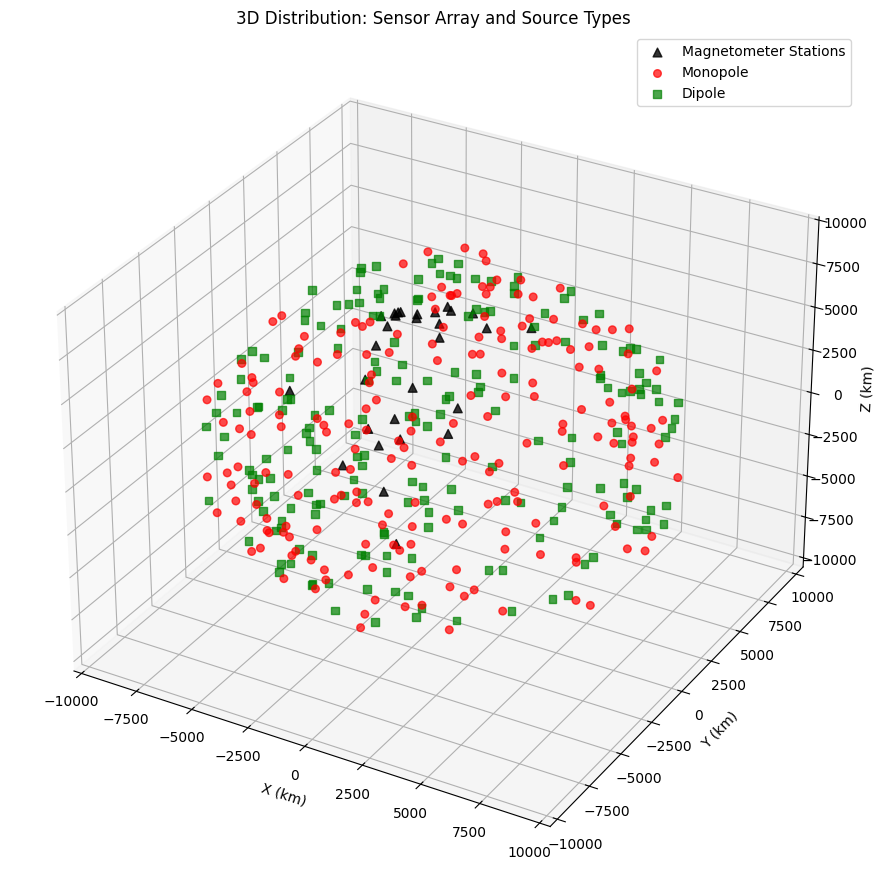

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_environment(sensor_locations, source_locations, source_types, n_samples=100):
    """
    Plots sensor array and sources, color-coded by pole type.
    source_types: list or array of indices/labels corresponding to source_locations
    """
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')

    # 1. Plot Sensors
    ax.scatter(sensor_locations[:, 0], sensor_locations[:, 1], sensor_locations[:, 2],
               c='black', marker='^', label='Magnetometer Stations', s=40, alpha=0.8)

    # 2. Define Styles for Source Types
    # Assuming source_types are encoded: 0=Monopole, 1=Dipole, 2=Quadrupole
    styles = {
        0: {'color': 'red',    'marker': 'o', 'label': 'Monopole'},
        1: {'color': 'green',  'marker': 's', 'label': 'Dipole'},
    }

    # 3. Plot Sources
    subset_locs = source_locations[:n_samples]
    subset_types = source_types[:n_samples]

    for type_idx, style in styles.items():
        # Create a mask to pick out just this type
        mask = (subset_types == type_idx)
        ax.scatter(subset_locs[mask, 0], subset_locs[mask, 1], subset_locs[mask, 2],
                   c=style['color'], marker=style['marker'], label=style['label'], s=30, alpha=0.7)

    # 4. Aesthetics
    ax.set_title("3D Distribution: Sensor Array and Source Types")
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")
    ax.set_zlabel("Z (km)")
    ax.legend()

    plt.tight_layout()
    plt.show()

# To run this, you need a 'types' array corresponding to your grid_positions
# If you generated them in order (e.g., repeating [0, 1, 2] for each position):
all_types = np.tile([0, 1], len(grid_positions))[:len(grid_positions)]

visualize_environment(sensors_xyz_locations, grid_positions, all_types, n_samples=1000)